In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("সব লাইব্রেরি ঠিকভাবে কাজ করছে!")

সব লাইব্রেরি ঠিকভাবে কাজ করছে!


In [4]:
file_path = r"D:\My Work\Data science\Telco\telco.csv"
df = pd.read_csv(file_path)
df.head()


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [5]:
# ডাটার কলাম এবং টাইপ দেখা
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [6]:
# কলামের নামের স্পেস দূর করা
df.columns = [c.replace(' ', '_') for c in df.columns]

# আপনার নতুন টার্গেট কলামের নাম হবে 'Churn_Label'
print(df.columns)

Index(['Customer_ID', 'Gender', 'Age', 'Under_30', 'Senior_Citizen', 'Married',
       'Dependents', 'Number_of_Dependents', 'Country', 'State', 'City',
       'Zip_Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred_a_Friend', 'Number_of_Referrals', 'Tenure_in_Months', 'Offer',
       'Phone_Service', 'Avg_Monthly_Long_Distance_Charges', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Avg_Monthly_GB_Download',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Satisfaction_Score', 'Customer_Status', 'Churn_Label',
       'Churn_Score', 'CLTV', 'Churn_Category', 'Churn_Reason'],
      dtype='object')


In [7]:
# Yes = 1, No = 0
df['Churn_Label'] = df['Churn_Label'].map({'Yes': 1, 'No': 0})

# চ্যনালিসিসের জন্য দরকার নেই এমন কিছু কলাম বাদ দেওয়া
# যেমন: ল্যাটিটিউড, লঙ্গিটিউড, জিপ কোড ইত্যাদি
cols_to_drop = ['Customer_ID', 'Country', 'State', 'City', 'Zip_Code', 'Latitude', 'Longitude']
df.drop(columns=cols_to_drop, inplace=True)

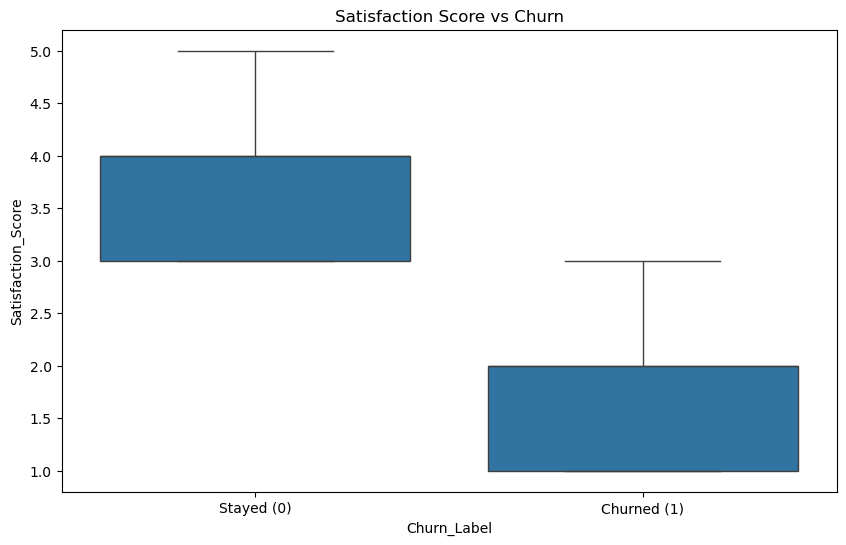

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn_Label', y='Satisfaction_Score', data=df)
plt.title('Satisfaction Score vs Churn')
plt.xticks([0, 1], ['Stayed (0)', 'Churned (1)'])
plt.show()

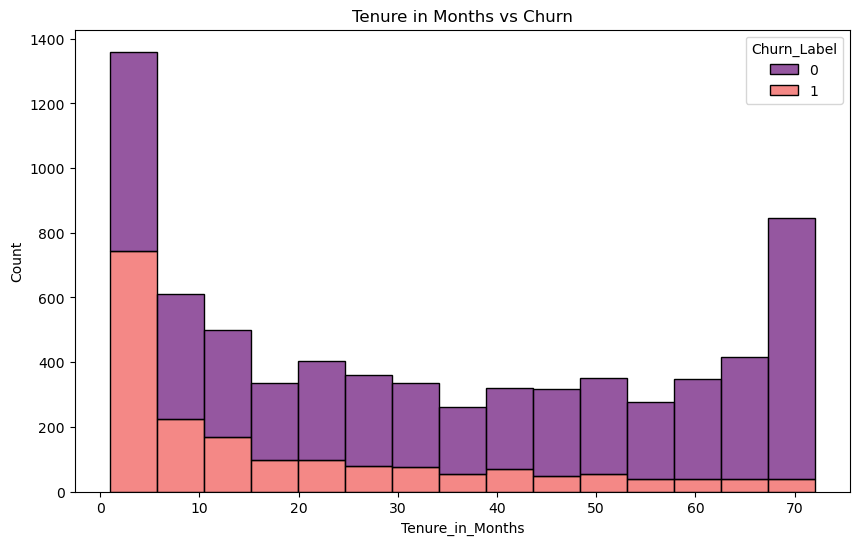

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Tenure_in_Months', hue='Churn_Label', multiple='stack', palette='magma')
plt.title('Tenure in Months vs Churn')
plt.show()

In [10]:
# টেক্সট কলামগুলোকে ক্যাটাগরি হিসেবে চিহ্নিত করা এবং সংখ্যায় রূপান্তর (One-Hot Encoding)
# আমরা শুধু গুরুত্বপূর্ণ কিছু কলাম বেছে নিচ্ছি মডেলিংয়ের জন্য
selected_features = ['Gender', 'Age', 'Married', 'Number_of_Referrals', 'Tenure_in_Months', 
                     'Offer', 'Phone_Service', 'Internet_Service', 'Internet_Type', 
                     'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charge', 
                     'Satisfaction_Score', 'Churn_Label']

df_final = df[selected_features].copy()

# ক্যাটেগরিক্যাল কলামগুলোকে ডামি ভেরিয়েবলে রূপান্তর
df_final = pd.get_dummies(df_final, drop_first=True)

# নতুন ডাটাফ্রেমের চেহারা দেখা
df_final.head()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Satisfaction_Score,Churn_Label,Gender_Male,Married_Yes,Offer_Offer B,Offer_Offer C,...,Offer_Offer E,Phone_Service_Yes,Internet_Service_Yes,Internet_Type_DSL,Internet_Type_Fiber Optic,Contract_One Year,Contract_Two Year,Paperless_Billing_Yes,Payment_Method_Credit Card,Payment_Method_Mailed Check
0,78,0,1,39.65,3,1,True,False,False,False,...,False,False,True,True,False,False,False,True,False,False
1,74,1,8,80.65,3,1,False,True,False,False,...,True,True,True,False,True,False,False,True,True,False
2,71,0,18,95.45,2,1,True,False,False,False,...,False,True,True,False,True,False,False,True,False,False
3,78,1,25,98.50,2,1,False,True,False,True,...,False,True,True,False,True,False,False,True,False,False
4,80,1,37,76.50,2,1,False,True,False,True,...,False,True,True,False,True,False,False,True,False,False


In [11]:
# ১. মডেলিংয়ের জন্য প্রয়োজনীয় কলামগুলো বেছে নেওয়া
# আমরা এমন কলামগুলো নেব যা দেখে মনে হচ্ছে চর্নের ওপর প্রভাব আছে
features = ['Age', 'Number_of_Referrals', 'Tenure_in_Months', 'Monthly_Charge', 
            'Satisfaction_Score', 'Gender', 'Married', 'Offer', 'Phone_Service', 
            'Internet_Service', 'Contract', 'Paperless_Billing']

X = df[features].copy()
y = df['Churn_Label']

# ২. টেক্সট কলামগুলোকে সংখ্যায় (০ এবং ১) রূপান্তর করা
X = pd.get_dummies(X, drop_first=True)

# ৩. ডাটাকে ট্রেনিং এবং টেস্টিং সেটে ভাগ করা (৮০% ট্রেনিং, ২০% টেস্টিং)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("ট্রেনিং ডাটার সাইজ:", X_train.shape)
print("টেস্টিং ডাটার সাইজ:", X_test.shape)

ট্রেনিং ডাটার সাইজ: (5634, 16)
টেস্টিং ডাটার সাইজ: (1409, 16)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# মডেল তৈরি এবং ট্রেনিং
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# প্রিডিকশন বা ভবিষ্যদ্বাণী করা
y_pred = model.predict(X_test)

# রেজাল্ট দেখা
print(f"মডেলের নির্ভুলতা (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nবিস্তারিত রিপোর্ট:")
print(classification_report(y_test, y_pred))

মডেলের নির্ভুলতা (Accuracy): 0.94

বিস্তারিত রিপোর্ট:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1009
           1       0.96      0.83      0.89       400

    accuracy                           0.94      1409
   macro avg       0.95      0.91      0.93      1409
weighted avg       0.94      0.94      0.94      1409



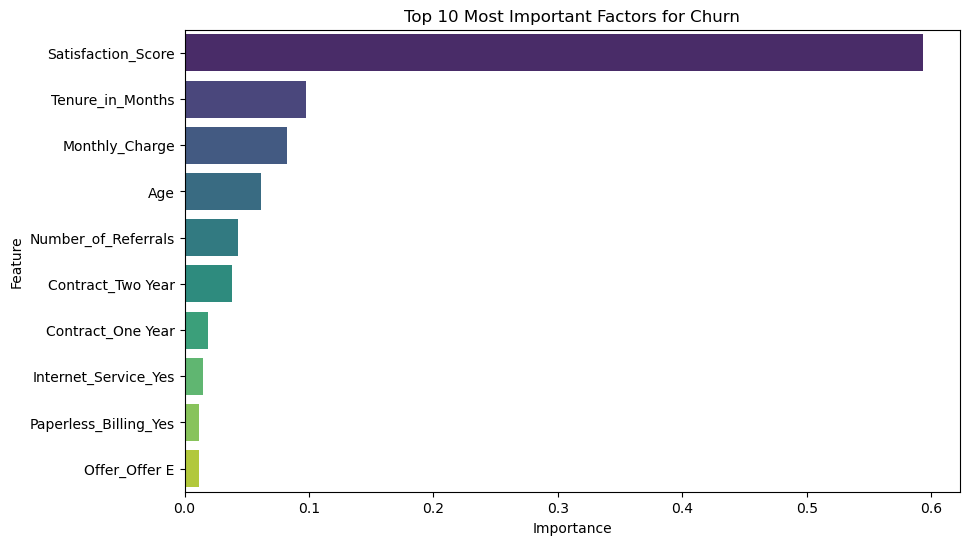

In [14]:
# কোন বৈশিষ্ট্যগুলো সবচেয়ে গুরুত্বপূর্ণ তা দেখা
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# গ্রাফ তৈরি (ওয়ার্নিং ফিক্স করা হয়েছে)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    hue='Feature',      # এখানে 'Feature' কলামটি 'hue' হিসেবে যোগ করা হয়েছে
    palette='viridis', 
    legend=False        # লিজেন্ড বন্ধ করে দেওয়া হয়েছে
)
plt.title('Top 10 Most Important Factors for Churn')
plt.show()